In [ ]:
import sys

sys.path.append("..")


from src.plotting.feature_plotting import plot_graph
import matplotlib.pyplot as plt
import numpy as np
import torch

DATA_DIR = "../mu3e_trigger_data"
MODEL_DIR = "../models"
PLOTS_DIR = "../plots"
SIGNAL_PIXEL_FILE = f"{DATA_DIR}/sig_with_layer_pixel_spacetime.npy"
BACKGROUND_PIXEL_FILE = f"{DATA_DIR}/bg_with_layer_pixel_spacetime.npy"
SIGNAL_MPPC_FILE = f"{DATA_DIR}/sig_with_layer_mppc_spacetime.npy"
BACKGROUND_MPPC_FILE = f"{DATA_DIR}/bg_with_layer_mppc_spacetime.npy"
SIGNAL_ONLY_PIXEL_FILE = f"{DATA_DIR}/sig_only_with_layer_pixel_spacetime.npy"
SIGNAL_ONLY_MPPC_FILE = f"{DATA_DIR}/sig_only_with_layer_mppc_spacetime.npy"


bg_pixel_spacetime = np.load(BACKGROUND_PIXEL_FILE)
bg_mppc_spacetime = np.load(BACKGROUND_MPPC_FILE)
sig_pixel_spacetime = np.load(SIGNAL_PIXEL_FILE)
sig_mppc_spacetime = np.load(SIGNAL_MPPC_FILE)
sig_only_pixel_spacetime = np.load(SIGNAL_ONLY_PIXEL_FILE)
sig_only_mppc_spacetime = np.load(SIGNAL_ONLY_MPPC_FILE)

In [ ]:
import src.torch.pre_processing.graph_batching as graph_batching
from importlib import reload

reload(graph_batching)

graph_builder = graph_batching.CombinedGraphBuilder(
    connect_layers=True, mppc_timing_cutoff=0.1
)
hetero_builder = graph_batching.HeteroGraphBuilder(
    connect_layers=True, mppc_timing_cutoff=0.1
)
layer_hetero_builder = graph_batching.LayerSeparatedHeteroGraphBuilder(
    connect_layers=True, mppc_timing_cutoff=0.1
)
event_processor = graph_batching.EventProcessor(graph_builder=graph_builder)
hetero_event_processor = graph_batching.EventProcessor(graph_builder=hetero_builder)
layer_hetero_event_processor = graph_batching.EventProcessor(
    graph_builder=layer_hetero_builder
)

Event has 6 MPPC hits and 5 Pixel hits


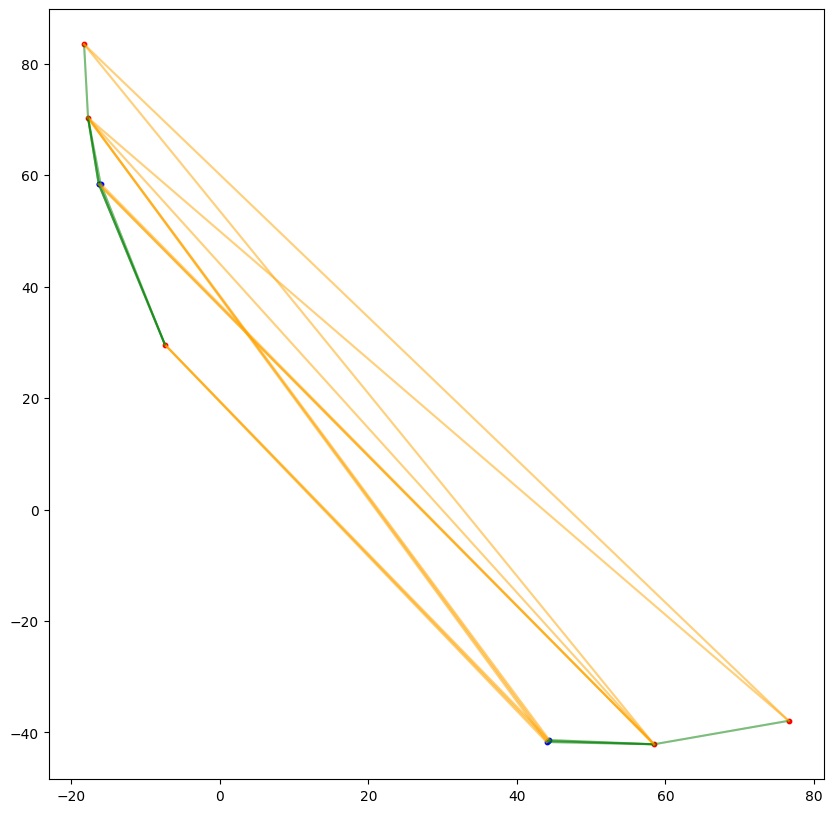

In [ ]:
event_id = 0
graphs_bg = event_processor.process_single_event(
    X_pixel=sig_only_pixel_spacetime[event_id],
    X_mppc=sig_only_mppc_spacetime[event_id],
    labels=None,
)

fig, ax = plt.subplots(1, figsize=(10, 10))
graph = graphs_bg[0]
mppc_nodes = graph.x[graph.x[:, 3] == 0]
pixel_nodes = graph.x[graph.x[:, 3] == 1]
ax.scatter(mppc_nodes[:, 0], mppc_nodes[:, 1], c="blue", s=10, label="MPPC hits")
ax.scatter(pixel_nodes[:, 0], pixel_nodes[:, 1], c="red", s=10, label="Pixel hits")
for edge_index in range(graph.edge_index.shape[1]):
    edge = graph.edge_index[:, edge_index]
    if graph.edge_labels[edge_index] == 1:
        color = "green"
    else:
        color = "orange"
    ax.plot(
        [graph.x[edge[0], 0], graph.x[edge[1], 0]],
        [graph.x[edge[0], 1], graph.x[edge[1], 1]],
        c=color,
        alpha=0.3,
    )
print(
    f"Event has {(graph.x[:, 3] == 0).sum()} MPPC hits and {(graph.x[:, 3] == 1).sum()} Pixel hits"
)

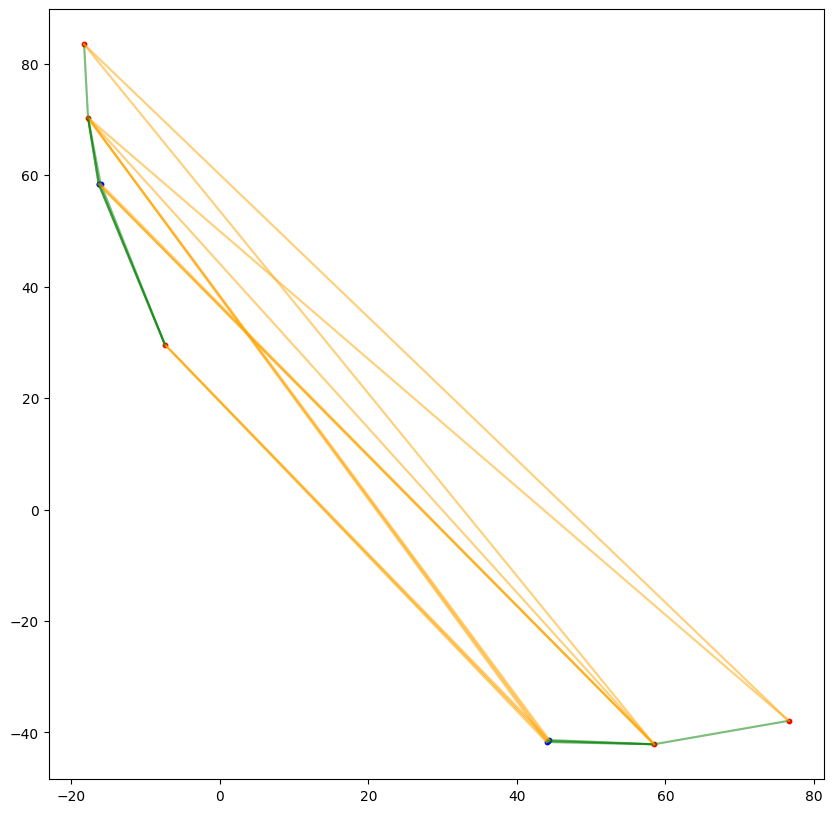

In [ ]:
event_id = 0
graphs_bg = hetero_event_processor.process_single_event(
    X_pixel=sig_only_pixel_spacetime[event_id],
    X_mppc=sig_only_mppc_spacetime[event_id],
    labels=None,
)
graphs_bg[0]
fig, ax = plt.subplots(1, figsize=(10, 10))
graph = graphs_bg[0]
mppc_nodes = graph.x_dict["mppc"]
pixel_nodes = graph.x_dict["pixel"]
ax.scatter(mppc_nodes[:, 0], mppc_nodes[:, 1], c="blue", s=10, label="MPPC hits")
ax.scatter(pixel_nodes[:, 0], pixel_nodes[:, 1], c="red", s=10, label="Pixel hits")
for edge_type, edge_index in graph.edge_index_dict.items():
    src, _, dst = edge_type
    for edge_idx in range(edge_index.shape[1]):
        edge = edge_index[:, edge_idx]
        if graph.edge_labels_dict[edge_type][edge_idx] == 1:
            color = "green"
        else:
            color = "orange"
        ax.plot(
            [
                graph.x_dict[edge_type[0]][edge[0], 0],
                graph.x_dict[edge_type[2]][edge[1], 0],
            ],
            [
                graph.x_dict[edge_type[0]][edge[0], 1],
                graph.x_dict[edge_type[2]][edge[1], 1],
            ],
            c=color,
            alpha=0.3,
        )

In [ ]:
event_id = 1
layer_graphs_bg = layer_hetero_event_processor.process_single_event(
    X_pixel=sig_only_pixel_spacetime[event_id],
    X_mppc=sig_only_mppc_spacetime[event_id],
    labels=None,
)

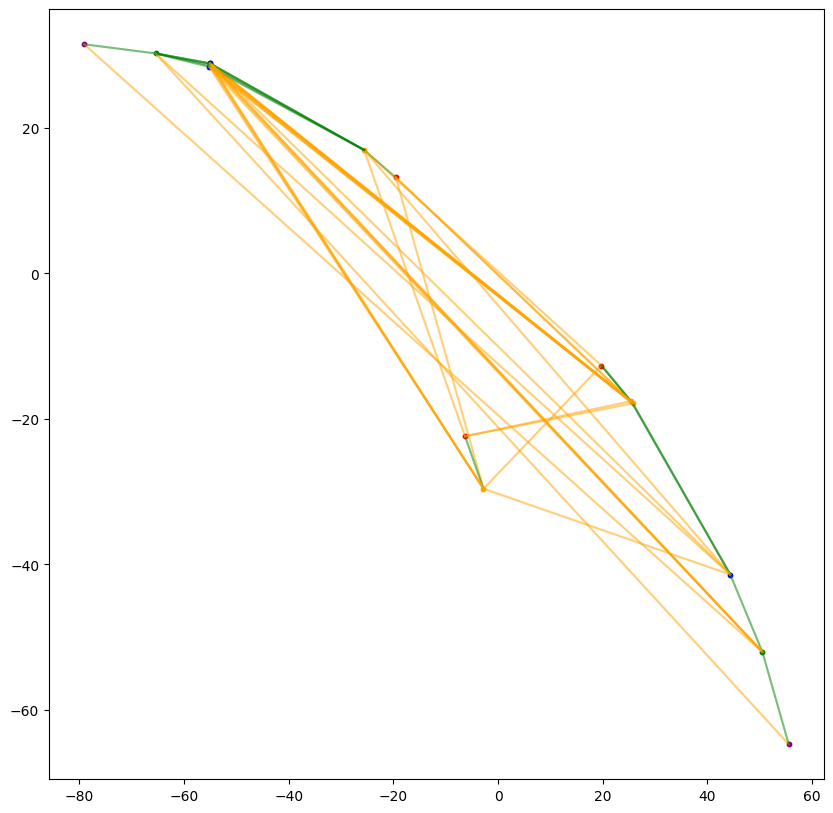

In [ ]:
layer_graphs_bg[0]
fig, ax = plt.subplots(1, figsize=(10, 10))
graph = layer_graphs_bg[0]
mppc_nodes = graph.x_dict["mppc"]
layer_1_nodes = graph.x_dict["layer_1"]
layer_2_nodes = graph.x_dict["layer_2"]
layer_3_nodes = graph.x_dict["layer_3"]
layer_4_nodes = graph.x_dict["layer_4"]
ax.scatter(mppc_nodes[:, 0], mppc_nodes[:, 1], c="blue", s=10, label="MPPC hits")
ax.scatter(
    layer_1_nodes[:, 0], layer_1_nodes[:, 1], c="red", s=10, label="Layer 1 Pixel hits"
)
ax.scatter(
    layer_2_nodes[:, 0],
    layer_2_nodes[:, 1],
    c="orange",
    s=10,
    label="Layer 2 Pixel hits",
)
ax.scatter(
    layer_3_nodes[:, 0],
    layer_3_nodes[:, 1],
    c="green",
    s=10,
    label="Layer 3 Pixel hits",
)
ax.scatter(
    layer_4_nodes[:, 0],
    layer_4_nodes[:, 1],
    c="purple",
    s=10,
    label="Layer 4 Pixel hits",
)
for edge_type, edge_index in graph.edge_index_dict.items():
    src, _, dst = edge_type
    for edge_idx in range(edge_index.shape[1]):
        edge = edge_index[:, edge_idx]
        if graph.edge_labels_dict[edge_type][edge_idx] == 1:
            color = "green"
        else:
            color = "orange"
        ax.plot(
            [
                graph.x_dict[edge_type[0]][edge[0], 0],
                graph.x_dict[edge_type[2]][edge[1], 0],
            ],
            [
                graph.x_dict[edge_type[0]][edge[0], 1],
                graph.x_dict[edge_type[2]][edge[1], 1],
            ],
            c=color,
            alpha=0.3,
        )